### Overview

[TESSERA](https://github.com/ucam-eo/geotessera) is an open foundation model for Earth observation that learns such embeddings from satellite yearly time-series of Sentinel-1 and Sentinel-2 satellite imagery. The resulting embeddings are produced at 10m resolution have 128-dimensions. They represent the pixel's full annual history and can be directly used for downstream tasks. Here we use the precomputed embeddings as input features for unsupervised classification task. 

Instead of using all the 128-bands, we first use Uniform Manifold Approximation and Projection (UMAP) to reduce the dimensions to 3. We train a [Parametric UMAP](https://umap-learn.readthedocs.io/en/latest/transform_landmarked_pumap.html) model on a subset of the input pixels and apply it on the entire dataset. Once we have the representation of the original embeddings in a 3-dimensional space, we apply a clustering model and apply the [WaterDetect algorithm](https://courses.spatialthoughts.com/python-remote-sensing.html#unsupervised-classification) to automatically detect the water cluster.

> As of July 2026, effort is underway to release these embeddings in a standard cloud-native format, and [processing is underway](https://github.com/ucam-eo/geotessera/issues/303) for them to be released on Source Cooperative. This notebook will be updated to use the cloud-native embeddings once they are available.


### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install rioxarray dask['distributed'] scikit-learn \
      geotessera umap-learn tensorflow

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask.array as da
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import rasterio
import rioxarray as rxr
import tempfile
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from umap.parametric_umap import ParametricUMAP
import xarray as xr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from geotessera.core import GeoTessera

### Load Multiband Composite

Load the multiband composite saved by the previous notebook in this section `01_preparing_composites.ipynb`. The composite contains 13 bands: 6 raw spectral bands (red, green, blue, nir, swir16, swir22), 5 precomputed indices (ndvi, ndbi, bsi, mndwi, ndwi), 2 bands derived from a DEM (elevation, slope) and 2 bands of X and Y coordinates.

In [ ]:
multiband_composite_path = os.path.join(data_folder, 'multiband_composite.tif')
if not os.path.exists(multiband_composite_path):
    print(f'Composite file not found at {multiband_composite_path}.',
          'Using default composite.')
    multiband_composite_path = (
        'https://storage.googleapis.com/spatialthoughts-public-data'
        '/python-remote-sensing/multiband_composite.tif')

band_names = ['red', 'green', 'blue', 'nir', 'swir16', 'swir22',
              'ndvi', 'ndbi', 'bsi', 'mndwi', 'ndwi', 'elevation', 'slope',
              'x_coord', 'y_coord']
composite_da = rxr.open_rasterio(
    multiband_composite_path,
    masked=True,
    chunks={'x': 1024, 'y': 1024},
)
composite_da = composite_da.assign_coords(band=band_names)
composite = composite_da.to_dataset('band')
composite

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

aoi_gdf = gpd.read_file(aoi_filepath)
geometry = aoi_gdf.geometry.union_all()
geometry

### Load TESSERA Embeddings


We take the bounding box of our area of interest in geographic coordinates (longitude/latitude). GeoTessera uses this to work out which embedding tiles cover the region.

In [ ]:
# (min_lon, min_lat, max_lon, max_lat) in EPSG:4326
bbox = geometry.bounds
bbox

We use the `geotessera` package to work with TESSERA embeddings. Rather than loading a full mosaic covering the whole AOI up front, embeddings are fetched tile-by-tile to avoid running out of memory.

We initialize a `GeoTessera` client and set the `embeddings_dir` to the `data_folder`. Any tile downloaded will be cached in that folder and whenever it is needed again - it is read back from the local cache instead of being re-downloaded.

In [ ]:
year = 2023
gt = GeoTessera(embeddings_dir=data_folder)

We use the `load_blocks_for_region()` function to find all intersecting tiles.

In [ ]:
tiles_to_fetch = gt.registry.load_blocks_for_region(bbox, year)
tiles_to_fetch

### Reduce Dimensionality with UMAP

TESSERA embeddings have 128 dimensions. We reduce them to 3 dimensions with UMAP before clustering, standardizing first with scikit-learn's [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) since UMAP relies on distances between points.

Sample a small subset of pixels from each tile to train the dimensionality reduction and clustering models. This will download the tiles locally and cache them for subsequent use.

In [ ]:
%%time
sample_rate = 0.0005  # 0.05% of pixels per tile

sampled_pixels = []
for year_val, tile_lon, tile_lat in tiles_to_fetch:
    embedding_tile, _, _ = gt.fetch_embedding(tile_lon, tile_lat, year_val)
    data_reshaped = embedding_tile.reshape(-1, embedding_tile.shape[-1])
    valid_data = data_reshaped[~np.isnan(data_reshaped).any(axis=1)]

    n_samples = int(len(valid_data) * sample_rate)
    indices = np.random.choice(len(valid_data), size=n_samples, replace=False)
    sampled_pixels.append(valid_data[indices])

sample = np.vstack(sampled_pixels)
print(f'Sampled {len(sample)} pixels from {len(tiles_to_fetch)} tiles')
sample

Train a [Parametric UMAP](https://umap-learn.readthedocs.io/en/latest/transform_landmarked_pumap.html) model.

In [ ]:
scaler = StandardScaler()
sample_scaled = scaler.fit_transform(sample)

umap_n_components = 3
umap_n_neighbors = 15
umap_min_dist = 0.1
umap_metric = 'euclidean'

reducer = ParametricUMAP(
    n_components=umap_n_components,
    n_neighbors=umap_n_neighbors,
    min_dist=umap_min_dist,
    metric=umap_metric,
    random_state=42,
)

In [ ]:
%%time
sample_reduced = reducer.fit_transform(sample_scaled)
sample_reduced

### Fetch Tiles and Apply UMAP Projection

For every TESSERA tile covering the AOI, fetch the raw embeddings and apply the trained scaler and Parametric UMAP model to reduce each tile to 3 bands, writing the result straight to disk as we go. At any point in the loop only a single tile's embeddings are in memory.

In [ ]:
umap_bands_path = os.path.join(output_folder, 'umap_bands.tif')

with tempfile.TemporaryDirectory() as tile_dir:
    tile_paths = []

    for year_val, tile_lon, tile_lat in tiles_to_fetch:
        print(f'Fetching {tile_lon}, {tile_lat}')
        embedding_tile, tile_crs, tile_transform = gt.fetch_embedding(tile_lon, tile_lat, year_val)

        # embedding shape: (height, width, 128)
        height, width, channels = embedding_tile.shape
        data_reshaped = embedding_tile.reshape(-1, channels)

        # Remove NaN/invalid values
        valid_mask = ~np.isnan(data_reshaped).any(axis=1)
        valid_data = data_reshaped[valid_mask]

        reduced = np.full((height * width, umap_n_components), np.nan, dtype='float32')
        if valid_data.size > 0:
            # UMAP-reduce once; the mosaicked result is reused later for both
            # the RGB visualization and the clustering step
            print(f'Transforming {tile_lon}, {tile_lat}')

            reduced[valid_mask] = reducer.transform(scaler.transform(valid_data))

        # Reshape back to the tile's spatial grid, bands first
        reduced = reduced.reshape(height, width, umap_n_components).transpose(2, 0, 1)

        tile_path = os.path.join(tile_dir, f'tile_{tile_lon:.2f}_{tile_lat:.2f}.tif')
        tile_profile = {
            'driver': 'GTiff', 'height': height, 'width': width, 'count': umap_n_components,
            'dtype': 'float32', 'crs': tile_crs, 'transform': tile_transform,
            'nodata': np.nan, 'compress': 'deflate',
        }
        with rasterio.open(tile_path, 'w', **tile_profile) as dst:
            dst.write(reduced)
        tile_paths.append(tile_path)

    print(f'Wrote {len(tile_paths)} UMAP-transformed tiles')

    # rasterio.merge() assumes every input shares one CRS — it does not reproject.
    # TESSERA tiles for a small AOI are normally all in the same UTM zone, but if
    # the AOI happened to straddle a zone boundary, merging mismatched-CRS tiles
    # directly would silently misalign the mosaic. Before merging, we check each
    # tile's CRS and reproject only the ones that don't match the majority CRS.
    tile_crs_list = [rasterio.open(p).crs for p in tile_paths]
    target_crs = max(set(tile_crs_list), key=tile_crs_list.count)

    if len(set(tile_crs_list)) > 1:
        print(f'Tiles span {len(set(tile_crs_list))} distinct CRS; reprojecting outliers to {target_crs}')

    normalized_paths = []
    for path, crs in zip(tile_paths, tile_crs_list):
        if crs == target_crs:
            normalized_paths.append(path)
            continue
        reproj_path = path.replace('.tif', '_reproj.tif')
        with rasterio.open(path) as src:
            transform, dst_width, dst_height = calculate_default_transform(
                src.crs, target_crs, src.width, src.height, *src.bounds)
            profile = src.profile.copy()
            profile.update(crs=target_crs, transform=transform, width=dst_width, height=dst_height)
            with rasterio.open(reproj_path, 'w', **profile) as dst:
                for band in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, band),
                        destination=rasterio.band(dst, band),
                        src_transform=src.transform, src_crs=src.crs,
                        dst_transform=transform, dst_crs=target_crs,
                        # bilinear since these are continuous UMAP components,
                        # not class labels
                        resampling=Resampling.bilinear)
        normalized_paths.append(reproj_path)

    src_files = [rasterio.open(p) for p in normalized_paths]
    mosaic, out_transform = merge(src_files)

    out_profile = src_files[0].profile.copy()
    out_profile.update({
        'driver': 'COG',
        'height': mosaic.shape[1],
        'width': mosaic.shape[2],
        'transform': out_transform,
    })

    with rasterio.open(umap_bands_path, 'w', **out_profile) as dst:
        dst.write(mosaic)

    for src in src_files:
        src.close()

print(f'Wrote {umap_bands_path}')

### Visualize the UMAP RGB Composite

Load the mosaicked UMAP bands and clip to the AOI.

In [ ]:
umap_ds = rxr.open_rasterio(umap_bands_path)
aoi_gdf_reprojected = aoi_gdf.to_crs(umap_ds.rio.crs)
umap_clipped = umap_ds.rio.clip(aoi_gdf_reprojected.geometry)

Display as a false-color RGB image using the percentile stretch computed from the training sample.

In [ ]:
def normalize_to_rgb(values, p_low, p_high):
    clipped = np.clip(values, p_low, p_high)
    scaled = (clipped - p_low) / (p_high - p_low)
    return (scaled * 255).astype('uint8')

rgb_p_low = np.percentile(sample_reduced, 2, axis=0)
rgb_p_high = np.percentile(sample_reduced, 98, axis=0)

/var/folders/19/9zfvytrj1gbc3sgt0xnm_sdr0000gn/T/ipykernel_53336/2725346385.py:4: RuntimeWarning: invalid value encountered in cast
  return (scaled * 255).astype('uint8')


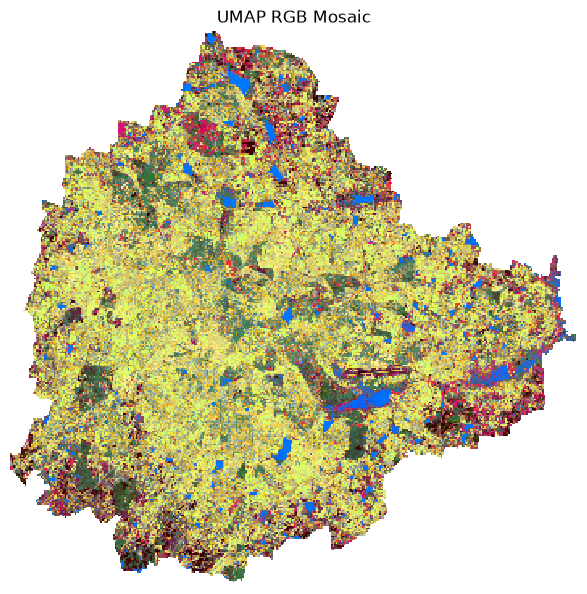

In [53]:
preview_umap = umap_clipped.rio.reproject(umap_clipped.rio.crs, resolution=100).compute()

# Pixels outside the AOI are NaN after clipping. normalize_to_rgb() cannot
# represent NaN in uint8, so add an alpha band and make those pixels
# transparent instead of opaque black.
valid = ~np.isnan(preview_umap.values).any(axis=0)
rgb = normalize_to_rgb(preview_umap.values.transpose(1, 2, 0), rgb_p_low, rgb_p_high)
alpha = np.where(valid, 255, 0).astype('uint8')
rgba = np.dstack([rgb, alpha])

preview_rgb_umap = xr.DataArray(
    rgba,
    dims=('y', 'x', 'band'),
    coords={'y': preview_umap.y, 'x': preview_umap.x, 'band': [0, 1, 2, 3]},
)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 6)
preview_rgb_umap.plot.imshow(ax=ax, rgb='band')
ax.set_title('UMAP RGB Mosaic')
ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Train a Clusterer

Here we use scikit-learn's `KMeans` with a fixed `n_clusters`. Adjust this value if water bodies are split across multiple clusters or merged with other land cover types.

In [ ]:
n_clusters = 6

model = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
model.fit(sample_reduced)
print(f'Trained KMeans with {n_clusters} clusters')

Run the KMeans model on the mosaiced UMAP bands to assign every pixel a cluster label, and write the result to disk.

In [ ]:
umap_arr = umap_clipped.compute()
channels, height, width = umap_arr.shape
pixels = umap_arr.values.transpose(1, 2, 0).reshape(-1, channels)
valid_mask = ~np.isnan(pixels).any(axis=1)

clusters_flat = np.full(pixels.shape[0], np.nan, dtype='float32')
clusters_flat[valid_mask] = model.predict(pixels[valid_mask]).astype('float32')

clusters_da = xr.DataArray(
    clusters_flat.reshape(height, width),
    dims=('y', 'x'),
    coords={'y': umap_clipped.y, 'x': umap_clipped.x},
    name='clusters',
).rio.write_crs(umap_clipped.rio.crs).rio.write_nodata(np.nan)


Visualize the clusters.

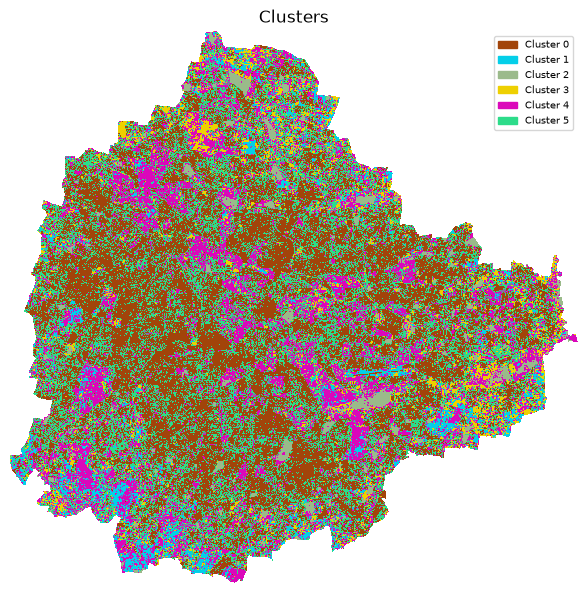

In [52]:
# Random distinct colors for each cluster
rng_colors = np.random.default_rng(0)
cluster_colors = rng_colors.random((n_clusters, 3))
cmap_clusters = mcolors.ListedColormap(cluster_colors)
preview_clusters = clusters_da.rio.reproject(
    clusters_da.rio.crs, resolution=50)


fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 6)

preview_clusters.plot.imshow(
    ax=ax,
    cmap=cmap_clusters,
    vmin=-0.5, vmax=n_clusters - 0.5,
    add_colorbar=False)
# Add cluster number labels to legend
handles = [mpatches.Patch(color=cluster_colors[c], label=f'Cluster {c}') for c in range(n_clusters)]
ax.legend(handles=handles, loc='upper right', fontsize=7)
ax.set_title('Clusters')
ax.set_axis_off()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Identify the Water Cluster

We compute the mean MNDWI for every cluster. Water bodies have distinctively high MNDWI values (typically > 0), so the cluster with the highest mean MNDWI is the water cluster.

In [ ]:
mndwi_da = composite['mndwi'].compute()
mndwi_da

In [ ]:
mndwi = mndwi_da.reindex_like(clusters_da, method='nearest')

# Group MNDWI by cluster label and compute mean per cluster, skipping NaN values
cluster_mndwi_mean = mndwi.groupby(clusters_da).mean(skipna=True)
cluster_mndwi_mean

In [ ]:
water_cluster = int(cluster_mndwi_mean.idxmax())

print('Mean MNDWI per cluster:')
for label, value in zip(cluster_mndwi_mean.clusters.values, cluster_mndwi_mean.values):
    marker = ' <-- water' if label == water_cluster else ''
    print(f'  Cluster {int(label)}: {float(value):+.4f}{marker}')

print(f'\nWater cluster: {water_cluster}')

Select all pixels belonging to the water cluster.

In [ ]:
water_mask = (clusters_da == water_cluster).astype('uint8')
water_mask = water_mask.rio.write_nodata(0)
water_mask


### Visualize Results

Plot the extracted water mask.

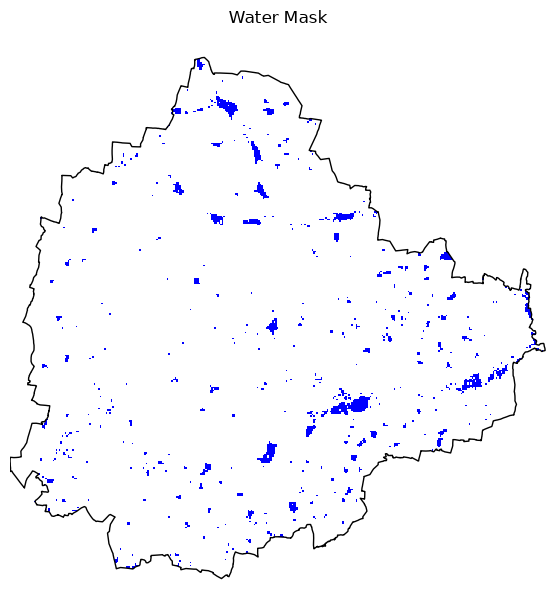

In [51]:
# Low-resolution preview
preview_water = water_mask.rio.reproject(water_mask.rio.crs, resolution=100)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(6, 6)

water_cmap = mcolors.ListedColormap(['white', 'blue'])
preview_water.plot.imshow(
    ax=ax,
    cmap=water_cmap,
    vmin=0, vmax=1,
    add_colorbar=False)
ax.set_title('Water Mask')

# Show AOI boundary
aoi_gdf_reprojected = aoi_gdf.to_crs(water_mask.rio.crs)
aoi_gdf_reprojected.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_axis_off()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### Save the Results

Save the result as a paletted Cloud-Optimized GeoTIFF to the configured output folder.

In [ ]:
clusters_file = f'clusters_{n_clusters}.tif'
clusters_path = os.path.join(output_folder, clusters_file)
clusters_da.rio.to_raster(clusters_path, driver='COG')
print(f'Wrote {clusters_path}')

In [ ]:
def write_cog_with_colormap(data_array, output_path, color_table):
    if data_array.dtype != np.dtype('uint8'):
        raise TypeError(f'data_array must be uint8 for a color table to attach')

    # Write to a temp file, add color table, then convert to COG
    tmp_path = output_path + '.tmp.tif'
    data_array.rio.to_raster(tmp_path)

    with rasterio.open(tmp_path) as src:
        profile = src.profile.copy()
        profile['driver'] = 'COG'
        data = src.read(1)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(data, 1)
            dst.write_colormap(1, color_table)

    os.remove(tmp_path)

In [ ]:
output_file = f'water_mask_{n_clusters}.tif'
output_path = os.path.join(output_folder, output_file)

# Define the color table: 0 for transparent, 1 for blue (RGBA)
color_table = {0: (0, 0, 0, 0), 1: (0, 0, 255, 255)}

write_cog_with_colormap(water_mask, output_path, color_table)
print(f'Saved {output_path}')